# Deep Ensemble OOD Detection (8 Points)

Train **10 EfficientNet-B0 models** on UC Merced (different seeds) and use
**variance across models** as an OOD score.

- UC Merced test → models agree → low variance
- FIDS30 → models disagree → high variance

In [1]:
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

NUM_CLASSES = 21
N_MODELS = 10
EPOCHS = 5
BATCH_SIZE = 64
LR = 1e-4
SEED = 42
SAVE_DIR = Path("ensemble_10")
SAVE_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Helpers

In [2]:
def build_model():
    return timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)

cfg = timm.data.resolve_model_data_config(build_model())
train_transform = timm.data.create_transform(**cfg, is_training=True)
val_transform = timm.data.create_transform(**cfg, is_training=False)

def train_one_model(k):
    """Train model k with its own seed, skip if checkpoint exists."""
    path = SAVE_DIR / f"model_{k}.pth"
    if path.exists():
        print(f"Model {k}: already exists, skipping")
        return

    print(f"\n=== Training Model {k+1}/{N_MODELS} (seed={SEED+k}) ===")
    torch.manual_seed(SEED + k)
    model = build_model().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    train_ds = datasets.ImageFolder("PrepData/UC_Merced/Training", transform=train_transform)
    val_ds = datasets.ImageFolder("PrepData/UC_Merced/Validation", transform=val_transform)
    g = torch.Generator().manual_seed(SEED + k)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True, generator=g)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=0, pin_memory=True)

    for epoch in range(EPOCHS):
        model.train()
        for images, t in tqdm(train_loader, desc=f"  Epoch {epoch+1}/{EPOCHS}", leave=False):
            images, t = images.to(device), t.to(device)
            loss = criterion(model(images), t)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, t in val_loader:
                images, t = images.to(device), t.to(device)
                correct += (model(images).argmax(1) == t).sum().item()
        print(f"  Epoch {epoch+1}: Val Acc={100*correct/len(val_ds):.2f}%")

    torch.save(model.state_dict(), path)
    print(f"  Saved to {path}")


def run_ensemble(loader):
    """Load each of N_MODELS checkpoints, run inference, stack softmax outputs.
    Returns tensor of shape (N_MODELS, N_samples, N_classes)."""
    passes = []
    for k in tqdm(range(N_MODELS), desc="Models"):
        model = build_model().to(device)
        model.load_state_dict(torch.load(SAVE_DIR / f"model_{k}.pth", map_location=device))
        model.eval()
        probs = []
        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)
                probs.append(F.softmax(model(images), dim=1).cpu())
        passes.append(torch.cat(probs))
    return torch.stack(passes)

## 1. Train 10 Models

Call the `train_one_model(k)` helper in a loop for `k = 0, 1, ..., N_MODELS-1`.

In [3]:
# TODO: Loop over k in range(N_MODELS) and call train_one_model(k) for each.
for k in range(N_MODELS):
    train_one_model(k)


=== Training Model 1/10 (seed=42) ===


  Epoch 1/5:   0%|          | 0/23 [00:00<?, ?it/s]

  Epoch 1: Val Acc=56.19%


  Epoch 2/5:   0%|          | 0/23 [00:00<?, ?it/s]

  Epoch 2: Val Acc=78.73%


...

  Epoch 3: Val Acc=88.25%


  Epoch 4/5:   0%|          | 0/23 [00:00<?, ?it/s]

  Epoch 4: Val Acc=92.38%


  Epoch 5/5:   0%|          | 0/23 [00:00<?, ?it/s]

  Epoch 5: Val Acc=93.97%
  Saved to ensemble_10/model_9.pth


## 2. Run Inference on UC Merced Test + FIDS30

In [4]:
uc_test_ds = datasets.ImageFolder("PrepData/UC_Merced/Test", transform=val_transform)
fids_ds = datasets.ImageFolder("PrepData/FIDS30", transform=val_transform)
uc_loader = DataLoader(uc_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
fids_loader = DataLoader(fids_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# TODO: Use run_ensemble(...) on both loaders to get uc_probs and fids_probs.
uc_probs = run_ensemble(uc_loader)
fids_probs = run_ensemble(fids_loader)

print(f"UC Merced probs shape: {uc_probs.shape}")   # (10, 315, 21)
print(f"FIDS30 probs shape:    {fids_probs.shape}")  # (10, 971, 21)

Models:   0%|          | 0/10 [00:00<?, ?it/s]

Models:   0%|          | 0/10 [00:00<?, ?it/s]

UC Merced probs shape: torch.Size([10, 315, 21])
FIDS30 probs shape:    torch.Size([10, 971, 21])


## 3. Variance as OOD Score

For each sample, compute the variance across the 10 model predictions,
then average over the class dimension to get a single scalar per sample.

In [5]:
# TODO: Compute per-sample variance across the model axis (dim=0),
#       then average over the class axis (dim=1). Convert to numpy.
# Hint: probs.var(dim=___).mean(dim=___).numpy()
uc_variance = uc_probs.var(dim=0).mean(dim=1).numpy()
fids_variance = fids_probs.var(dim=0).mean(dim=1).numpy()

print(f"UC Merced: mean variance = {uc_variance.mean():.4f}")
print(f"FIDS30:    mean variance = {fids_variance.mean():.4f}")
print(f"Ratio:     {fids_variance.mean() / uc_variance.mean():.2f}x")

UC Merced: mean variance = 0.0028
FIDS30:    mean variance = 0.0073
Ratio:     2.60x


## 4. Histogram + Threshold Analysis

Threshold at the **95th percentile** of in-distribution variance.
Flag samples ABOVE the threshold as OOD.

Threshold (95th pct of UC Merced variance): 0.0109
  False alarm rate: 5.1%
  Detection rate:   11.3%


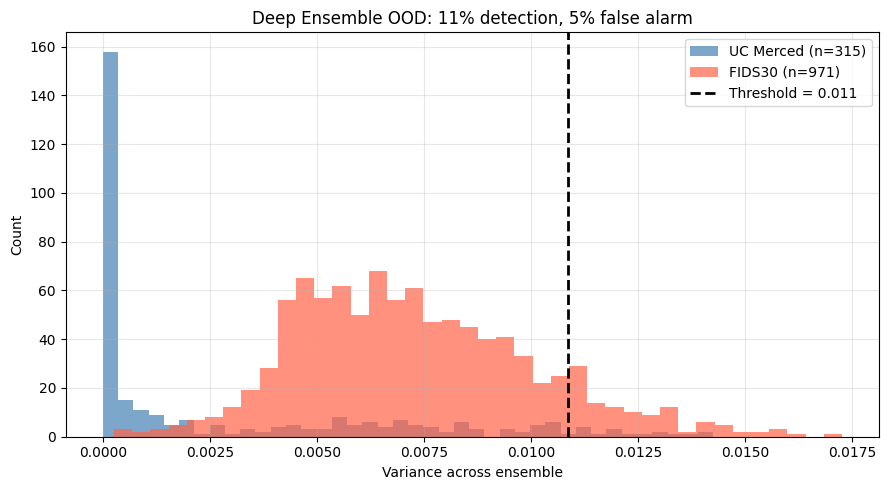

In [6]:
# TODO: Fill in the three values.
# Hint: np.percentile, element-wise comparison, .mean()
threshold = np.percentile(uc_variance, 95)
false_alarm = (uc_variance > threshold).mean()
detection = (fids_variance > threshold).mean()

print(f"Threshold (95th pct of UC Merced variance): {threshold:.4f}")
print(f"  False alarm rate: {false_alarm:.1%}")
print(f"  Detection rate:   {detection:.1%}")

# Histogram (provided)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(uc_variance, bins=40, alpha=0.7, label=f"UC Merced (n={len(uc_variance)})", color='steelblue')
ax.hist(fids_variance, bins=40, alpha=0.7, label=f"FIDS30 (n={len(fids_variance)})", color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f"Threshold = {threshold:.3f}")
ax.set_xlabel("Variance across ensemble")
ax.set_ylabel("Count")
ax.set_title(f"Deep Ensemble OOD: {detection:.0%} detection, {false_alarm:.0%} false alarm")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()